# Tool-using crows - Moll et al., 2025

Dataset includes behavioural data from 2 trials:

- Videos published in Moll et al., 2025¹, see available online [here](https://www.sciencedirect.com/science/article/pii/S0960982225011005?via%3Dihub#mmc1). We recorded with two cameras (`cam-1`, `cam-2`), but only video from left camera (`cam-2`) is shared.
- DeepLabCut² pose files generated for the videos of each camera and 3D pose file `*_DLC_3D.csv` generated using [3D triangulation](https://deeplabcut.github.io/DeepLabCut/docs/Overviewof3D.html). 
- Video features files (`_s3d.npy`) generated using the Video Features repository³
- `Trial_data.nc` file with behavioural features (kinematic, video features), changepoints, custom colours, and trial meta data. 

Below is a example script how one can generate the `Trial_data.nc` file from the raw data.



---

¹ Moll, F. W., Würzler, J., & Nieder, A. (2025). Learned precision tool use in carrion crows. Current Biology, 35(19), 4845-4852.e3. https://doi.org/10.1016/j.cub.2025.08.033

² Nath, T., Mathis, A., Chen, A. C., Patel, A., Bethge, M., & Mathis, M. W. (2019). Using DeepLabCut for 3D markerless pose estimation across species and behaviors. Nature Protocols, 14(7), 2152–2176. https://doi.org/10.1038/s41596-019-0176-0

³ Iashin, V. (2020). Video Features [Computer software]. https://github.com/v-iashin/video_features

<img src="assets/moll1.png" width="600">
<img src="assets/moll2.png" width="900">

Left: Figure 1C from Moll et al., 2025¹

Right: Screenshot from GUI. Bottom line plot shows speed of beak tip.

### File structure
```
Moll2025/
├── labels/                                    # GUI saved label files
├── 2024-12-17_115_Crow1-cam-1.mp4             # video (trial 115)
├── 2024-12-17_115_Crow1-cam-1DLC.csv          # 2D pose cam-1
├── 2024-12-17_115_Crow1-cam-2DLC.csv          # 2D pose cam-2
├── 2024-12-17_115_Crow1_DLC_3D.csv            # 3D triangulated pose
├── 2024-12-17_115_Crow1-cam-1_s3d.npy         # Video features
├
├── 2024-12-18_041_Crow1-cam-1.mp4             # video (trial 41)
├── 2024-12-18_041_Crow1-cam-1DLC.csv          # 2D pose cam-1
├── 2024-12-18_041_Crow1-cam-2DLC.csv          # 2D pose cam-2
├── 2024-12-18_041_Crow1_DLC_3D.csv            # 3D triangulated pose
├── 2024-12-18_041_Crow1-cam-1_s3d.npy         # Video features
└── Trial_data.nc                              # all behavioural and meta data in one place
```

### Filename convention

```
2024-12-17_115_Crow1-cam-1DLC.csv
2024-12-17_115_Crow1-cam-1.mp4
│            │   │
│            │   └── bird ID
│            └────── trial number
└─────────────────── session date
```
Using a similar file convention across related files (video, 2D pose, 3D pose), makes it easier to match file names across trials using `dt.set_media()`.

### Download example data


In [2]:
data_folder

WindowsPath('C:/Users/aksel/Documents/Code/ethograph/data/Moll2025')

In [1]:
from ethograph import get_project_root
from ethograph.utils.download import download_example_dataset

data_folder = get_project_root() / "data" / "Moll2025"
mapping_path = download_example_dataset("moll2025", data_folder)

print(f"\ndata_folder:   {data_folder}")
print(f"mapping_path:  {mapping_path}")

  2024-12-18_041_Crow1-cam-1_s3d.npy (11/11)
  mapping: C:\Users\aksel\Documents\Code\ethograph\data\Moll2025\.ethograph\mapping.txt

data_folder:   C:\Users\aksel\Documents\Code\ethograph\data\Moll2025
mapping_path:  C:\Users\aksel\Documents\Code\ethograph\data\Moll2025\.ethograph\mapping.txt


### Create dataset

In [1]:
import glob
import os
import warnings
import numpy as np
import xarray as xr

from movement.io import load_poses
from movement.kinematics import compute_pairwise_distances, compute_velocity, compute_acceleration
from movement.utils.vector import compute_norm

import ethograph as eto
from ethograph.utils.paths import extract_trial_info_from_filename
from ethograph.features.movement import compute_distance_to_constant, Position3DCalibration
from ethograph.features.changepoints import find_troughs_binary, find_nearest_turning_points_binary
from ethograph.features.preprocessing import gaussian_smoothing
warnings.filterwarnings(
    'ignore', 
    message='Confidence array was not provided.Setting to an array of NaNs',
    module='movement.validators.datasets'
)

# Config
data_folder = eto.get_project_root() / "data" / "Moll2025"
dlc_3d_paths = np.sort(glob.glob(os.path.join(data_folder, "*_3D.csv")))

fps = 200
clip_distance = 50 # Exclude unrealistic distance features (> 50cm)

smoothing_params = {"sigma": 1.5, "axis": 0, "mode": "constant", "cval": np.nan}


# We found out that using a subset of s3d video features 
# (with high Cohen's D for a label) works better than all 1024
good_s3d_feats = [ 326, 327, 292, 363, 219, 192, 260, 66, 332, 199,
       288, 763, 837, 182, 24, 218, 213, 21, 733, 242] # Crow 1


# Stationary locations
disp_xyz = [-10.23, -5.907, -1.395]
box1 = np.array([-7.08514973,  0.14055037,  0.58930513]) # front left
box2 = np.array([-6.97786264,  9.87752058,  0.96104736]) # back left
box3 = np.array([6.81007923, 9.72017014, 0.77115876]) # back right
box4 = np.array([ 6.77518696, -0.02424044,  0.60184316]) # front right


ds_list = []
video_files = []
pose_files = []
for dlc_3d_path in dlc_3d_paths:
    ds = load_poses.from_dlc_file(dlc_3d_path, fps=fps)

    # Meta data (available in filename)
    session_date, trial_num, bird = extract_trial_info_from_filename(dlc_3d_path)
    ds = ds.assign_coords(individuals=[bird])
    ds.attrs["trial"] = trial_num 

    
    
    # dlc_suffix = "DLC_resnet50_Felix_cross_SessionsAug1shuffle1_200000_filtered"
    
    # E.g. mapping trial 41 -> 2024-12-18_041_Crow1-cam-1.mp4
    base_name = os.path.basename(dlc_3d_path)
    video_files.append([
        base_name.replace("_DLC_3D.csv", "-cam-1.mp4"),
    ])
    pose_files.append([
        base_name.replace("_DLC_3D.csv", "-cam-1DLC.csv"),
    ])


    # Transform 2D pose -> 3D pose
    calibration = Position3DCalibration()
    ds = calibration.transform(ds)
    
     
    # Kinematic features
    ds["position"] = gaussian_smoothing(ds.position, **smoothing_params)
    ds["velocity"] = compute_velocity(ds.position.sel(keypoints=['stickTip', 'beakTip'])).clip(min=-150, max=150)
    ds["speed"] = compute_norm(ds.velocity.sel(keypoints=['stickTip', 'beakTip']))
    smooth_2x = {**smoothing_params, "sigma": smoothing_params["sigma"] * 2}
    position_smooth = gaussian_smoothing(ds.position, **smooth_2x)
    ds["acceleration"] = compute_acceleration(position_smooth.sel(keypoints=['stickTip', 'beakTip'])).clip(min=-1500, max=1500)
        
    

    # Distance features
    ds["pellet_beakTip_dist"] = compute_pairwise_distances(ds.position, "keypoints", {"pellet": "beakTip"}).clip(0, clip_distance)
    ds["pellet_stickTip_dist"] = compute_pairwise_distances(ds.position, "keypoints", {"pellet": "stickTip"}).clip(0, clip_distance)
    ds["disp_beakTip_dist"] = compute_distance_to_constant(ds.position, reference_point=disp_xyz, keypoint="beakTip").clip(0, clip_distance)
    ds["disp_stickTip_dist"] = compute_distance_to_constant(ds.position, reference_point=disp_xyz, keypoint="stickTip").clip(0, clip_distance)
    


    # Only keep subset of keypoints
    ds = ds.sel(keypoints=["beakTip", "stickTip", "pellet"])

    # Video Features (not included in GitHub release download)
    s3d_file = base_name.replace("_DLC_3D.csv", "-cam-1_s3d.npy")
    s3d_path = os.path.join(data_folder, s3d_file)
    if os.path.exists(s3d_path):
        s3d_data = np.load(s3d_path)
        ds["s3d"] = (("time", "s3d_dims"), s3d_data[:, good_s3d_feats])
    else:
        print(f"Skipping video features (not found): {s3d_file}")


    # Filter for variables shown in Feature DropDown ('Data controls')
    for var in ds.data_vars:
        ds[var].attrs["type"] = "features"
        
    
    # For changepoint correction on speed curve
    ds = eto.add_changepoints_to_ds(
        ds=ds, 
        target_feature="speed",
        changepoint_name="troughs", 
        changepoint_func=find_troughs_binary, 
        prominence=0.5, 
        distance=2
    )
    ds = eto.add_changepoints_to_ds(
        ds=ds,
        target_feature="speed",
        changepoint_name="turning_points",
        changepoint_func=find_nearest_turning_points_binary,
        threshold=1.0,
        max_value=50,
        prominence=5,
        width=2
    )
    
    # Colouring for Lineplots
    ds = eto.add_angle_rgb_to_ds(ds, smoothing_params=smoothing_params)
    
    
    # Trial meta data -> Filter trials in 'Navigation controls'
    if int(trial_num) == 41:
        ds.attrs["pellet_position"] = "right"
    if int(trial_num) == 115:
        ds.attrs["pellet_position"] = "left"

        
    ds_list.append(ds)
    
dt = eto.from_datasets(ds_list)
dt.attrs["session_date"] = session_date 


dt.set_media("video", video_files, device_labels=['cam-1'])
dt.set_media("pose", pose_files, device_labels=['cam-1'])


# dt.save(data_folder / "Trial_data_new.nc")

### Rewrite, include examples for pynapple construction

simplified version

In [7]:
from ethograph.features.changepoints import find_troughs_binary, find_nearest_turning_points_binary
from ethograph.io.pynapple import add_changepoints_to_nap, add_angle_rgb_to_nap
import pynapple as nap

speed_path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\pynapple\beakTip_speed.npz"
pos_path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\pynapple\beakTip_position.npz"


GAP = 10.0

all_speed = []
all_velocity = []
all_position = []
trial_starts = []
trial_ends = []

offset = 0.0

for trial in dt.trials:
    time = dt.trial(trial).time.values
    speed = dt.trial(trial).speed.sel(keypoints="beakTip").squeeze().values
    velocity = dt.trial(trial).velocity.sel(keypoints="beakTip").squeeze().values
    position = dt.trial(trial).position.sel(keypoints="beakTip").squeeze().values

    shifted_time = time - time[0] + offset
    trial_starts.append(shifted_time[0])
    trial_ends.append(shifted_time[-1])

    all_speed.append((shifted_time, speed))
    all_velocity.append((shifted_time, velocity))
    all_position.append((shifted_time, position))

    offset = shifted_time[-1] + GAP

t = np.concatenate([s[0] for s in all_speed])
trials = nap.IntervalSet(start=trial_starts, end=trial_ends)

speed_tsd = nap.Tsd(t=t, d=np.concatenate([s[1] for s in all_speed]), time_support=trials)
velocity_tdf = nap.TsdFrame(
    t=t, d=np.concatenate([s[1] for s in all_velocity]),
    columns=["x", "y", "z"], time_support=trials,
)
position_tdf = nap.TsdFrame(
    t=t, d=np.concatenate([s[1] for s in all_position]),
    columns=["x", "y", "z"], time_support=trials,
)

speed_troughs = add_changepoints_to_nap(
    speed_tsd,
    target_feature="speed",
    changepoint_func=find_troughs_binary,
    prominence=0.3,
)


# angle_rgb from position (2D xy input)
angle_rgb = add_angle_rgb_to_nap(
    position_tdf,
    smoothing_params={"sigma": 3},
    position_key="position",
    xy_columns=["x", "y"],
)


out = r"C:\Users\aksel\Desktop\temp"

speed_tsd.save(os.path.join(out, "beakTip_speed"))
velocity_tdf.save(os.path.join(out, "beakTip_velocity"))
position_tdf.save(os.path.join(out, "beakTip_position"))
trials.save(os.path.join(out, "trials"))
angle_rgb.save(os.path.join(out, "beakTip_angle_rgb"))
speed_troughs.save(os.path.join(out, "beakTip_speed_troughs"))

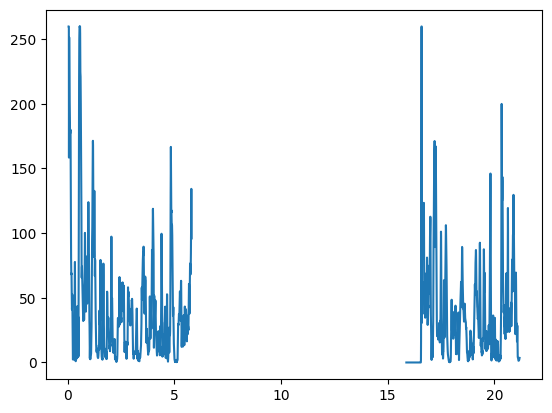

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(angle_rgb.t, angle_rgb.d[:, 0], color="r", label="R")
ax.plot(angle_rgb.t, angle_rgb.d[:, 1], color="g", label="G")
ax.plot(angle_rgb.t, angle_rgb.d[:, 2], color="b", label="B")

ax.set_xlabel("Time (s)")
ax.set_ylabel("RGB value")
ax.legend()
plt.show()

In [ ]:
from ethograph.features.changepoints import find_troughs_binary, find_nearest_turning_points_binary
from ethograph.io.pynapple import add_changepoints_to_nap, add_angle_rgb_to_nap
import pynapple as nap

speed_path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\pynapple\beakTip_speed.npz"
pos_path = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\pynapple\beakTip_position.npz"

smoothing_params = {"sigma": 1.5, "axis": 0, "mode": "constant", "cval": np.nan}


speed_tsd = nap.load_file(speed_path)
pos_tsd = nap.load_file(pos_path)



speed_troughs = add_changepoints_to_nap(
    speed_tsd,
    target_feature="speed",
    changepoint_func=find_troughs_binary,
    prominence=0.5, 
    distance=2
)


speed_troughs = add_changepoints_to_nap(
    speed_tsd,
    target_feature="speed",
    changepoint_func=find_nearest_turning_points_binary,
    threshold=1.0,
    max_value=50,
    prominence=5,
    width=2
)



# angle_rgb from position (2D xy input)
angles, angle_rgb = add_angle_rgb_to_nap(
    pos_tsd,
    smoothing_params=smoothing_params,
    position_key="position",
    xy_columns=["x", "y"],
)

### include some plotting examples, and highlighting changepoints

TODO
can link to in API, etc


In [ ]:
from ethograph.labels.intervals import load_label_mapping
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ethograph as eto
import pandas as pd

path = r"C:\Users\aksel\.ethograph\example_data\Moll2025\Trial_data.nc"
dt = eto.open(path)

path = r"C:\Users\aksel\.ethograph\example_data\Moll2025\Trial_data_labels.tsv"
df = pd.read_csv(path, sep="\t")

from ethograph.utils.paths import find_config
mapping = find_config("mapping.txt", data_folder)

time = dt.itrial(0).time.values
signal = dt.itrial(0).speed.sel(keypoints="beakTip").squeeze().values

mappings = load_label_mapping(mapping)
fig, ax = plt.subplots()
ax.plot(time, signal)

for _, row in df.iterrows():
    color = mappings[int(row["labels"])]["color"]  # (3,) RGB in [0, 1]
    ax.axvspan(row["onset_s"], row["offset_s"], alpha=0.5, color=color)

# Build a legend from the mapping
handles = [
    mpatches.Patch(color=m["color"], label=m["name"])
    for m in mappings.values()
]
ax.legend(handles=handles[:10]) # TODO: improve layout of example
plt.show()